# Prosper Loan Risk & Pricing Story: An Explanatory Analysis
by Waad

## Investigation Overview
The primary goal of this presentation is to explain how Prosper prices risk and how borrower credit tiers and performance statuses drive interest rates, moving from macro pricing trends to multi-dimensional credit behavior.

**Executive Summary / Key Insights**:
* **Risk-Based Pricing Banding**: Strong negative correlation ($r = -0.64$) between `ProsperScore` and `BorrowerRate`, proving step-wise structural rate adjustments for risk.
* **Credit Dominance over Income**: Multi-encoding visualizations reveal that `ProsperScore` dictates rate levels consistently, overriding `StatedMonthlyIncome` variance.
* **Performance Tier Polarization**: Defaulted and past-due loans cluster heavily around or above the global mean rate (~0.19), highlighting risk exposure concentrations.

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

In [3]:
# load in the dataset into a pandas dataframe
df = pd.read_csv('/content/prosperLoanData.csv')

**Purpose**: Show the structural relationship between credit risk scores and borrowing rates.
**Observation**: Borrower rates decrease systematically as Prosper scores increase (strong negative correlation, r = -0.64), proving strict risk-based pricing banding across tiers 1–11.

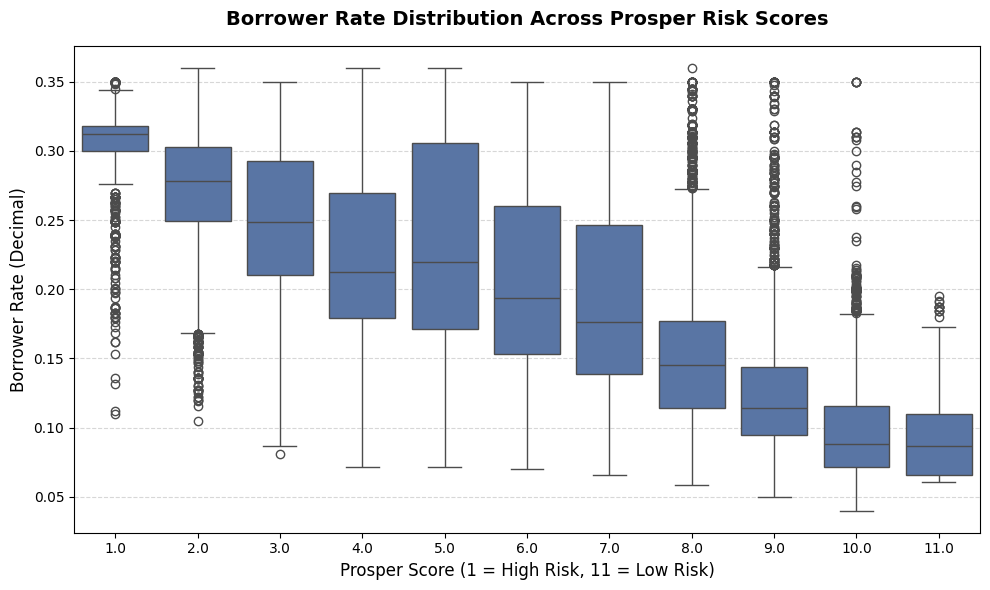

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='ProsperScore', y='BorrowerRate', color='#4c72b0')
plt.title('Borrower Rate Distribution Across Prosper Risk Scores', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Prosper Score (1 = High Risk, 11 = Low Risk)', fontsize=12)
plt.ylabel('Borrower Rate (Decimal)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Purpose**: Evaluate whether declared income overrides credit tier in rate pricing.
**Observation**: Credit score (color encoded) dictates interest rates consistently across all income spectrums, showing that higher Prosper scores secure lower rates regardless of `StatedMonthlyIncome` variance.

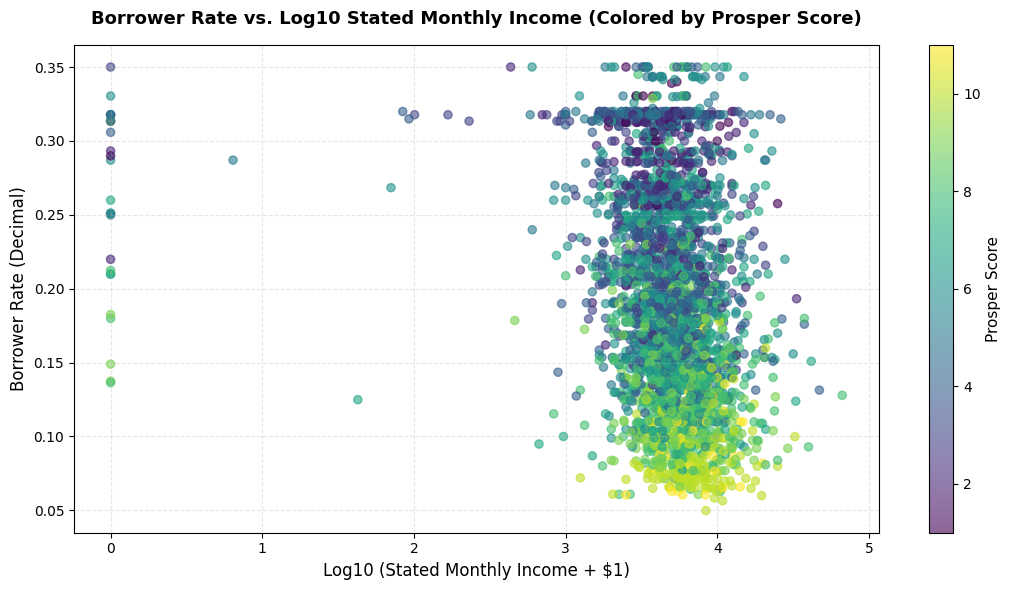

In [6]:
sample_df = df.dropna(subset=['ProsperScore', 'StatedMonthlyIncome', 'BorrowerRate']).sample(3000, random_state=42)

plt.figure(figsize=(11, 6))
plt.scatter(x=np.log10(sample_df['StatedMonthlyIncome'] + 1),
            y=sample_df['BorrowerRate'],
            c=sample_df['ProsperScore'],
            cmap='viridis', alpha=0.6, s=35)
cbar = plt.colorbar()
cbar.set_label('Prosper Score', fontsize=11)
plt.title('Borrower Rate vs. Log10 Stated Monthly Income (Colored by Prosper Score)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Log10 (Stated Monthly Income + $1)', fontsize=12)
plt.ylabel('Borrower Rate (Decimal)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Purpose**: Compare risk exposure and rate distribution across cleaned loan performance statuses against the global baseline.
**Observation**: Defaulted and past-due loans cluster heavily above or around the global mean rate (~0.19), whereas completed and current loans maintain a healthier distribution across lower-to-mid rate bands.

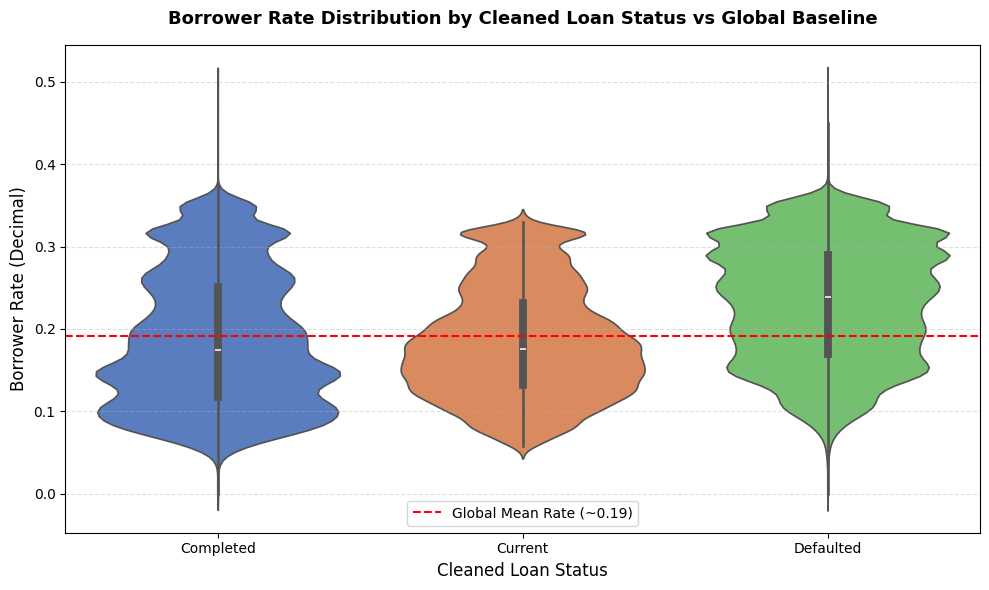

In [7]:
status_map = {'Completed': 'Completed', 'Current': 'Current',
              'Chargedoff': 'Defaulted', 'Defaulted': 'Defaulted'}
df['LoanStatusCleaned'] = df['LoanStatus'].map(status_map)
plot_df = df[df['LoanStatusCleaned'].isin(['Completed', 'Current', 'Defaulted'])]

global_mean = plot_df['BorrowerRate'].mean()

plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_df, x='LoanStatusCleaned', y='BorrowerRate', palette='muted')
plt.axhline(global_mean, color='red', linestyle='--', linewidth=1.5, label=f'Global Mean Rate (~{global_mean:.2f})')
plt.title('Borrower Rate Distribution by Cleaned Loan Status vs Global Baseline', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Cleaned Loan Status', fontsize=12)
plt.ylabel('Borrower Rate (Decimal)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()